# AI Translation Style Detection — Aggregate Pipeline

This notebook runs **Steps 2–7** of the pipeline end-to-end.  
**Prerequisite:** Step 1 must already have been executed so that `outputs/ai_translations.csv` exists.

| Step | Description | Key Outputs |
|------|------------|-------------|
| 2 | Fine-tune GPT-2 (LoRA) | `train_test_split.csv`, LoRA adapters, `finetune_summary.csv` |
| 3 | Cross-perplexity matrix | `perplexity_matrix.csv` |
| 4 | Classification & ablation | `classification_results.csv`, `roc_curves.png` |
| 5 | Token-level NLL annotation | `token_nll_annotations.csv`, `sentence_nll_summary.csv`, heatmap HTML |
| 6 | Probe translation models | `probe_results.csv` |
| 7 | Summary report | `summary_report.csv` |

> **GPU recommended.** Steps 2–6 use PyTorch and benefit heavily from CUDA.


## Environment Check

Verify required packages and GPU availability.

In [4]:
import torch, transformers, peft, datasets, sklearn, scipy
print(f'PyTorch       : {torch.__version__}')
print(f'Transformers  : {transformers.__version__}')
print(f'PEFT          : {peft.__version__}')
print(f'Datasets      : {datasets.__version__}')
print(f'scikit-learn  : {sklearn.__version__}')
print(f'SciPy         : {scipy.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device    : {torch.cuda.get_device_name(0)}')


PyTorch       : 2.1.1+cu121
Transformers  : 4.35.2
PEFT          : 0.6.2
Datasets      : 2.14.5
scikit-learn  : 1.3.0
SciPy         : 1.11.2
CUDA available: True
GPU device    : NVIDIA RTX A6000


## Compatibility Note

The `TrainingArguments` parameter for evaluation strategy changed name across `transformers` versions:
- **< 4.41.0**: `evaluation_strategy`
- **≥ 4.41.0**: `eval_strategy` (old name deprecated)

This notebook uses `evaluation_strategy` for broad compatibility. If you see a deprecation warning, you can safely ignore it or upgrade `transformers`.

## Verify Prerequisites

Check that `config.py`, `utils.py`, and the Step 1 output exist.

In [5]:
import os, config
from utils import ensure_dir

ai_path = os.path.join(config.OUTPUT_DIR, 'ai_translations.csv')
assert os.path.isfile(ai_path), (
    f'ai_translations.csv not found at {ai_path}. '
    'Please run Step 1 first to generate it.'
)
print(f'✓ ai_translations.csv found at {ai_path}')
print(f'✓ Output directory : {config.OUTPUT_DIR}')
print(f'✓ Primary model    : {config.PRIMARY_MODEL_NAME}')
print(f'✓ Device           : {config.DEVICE}')


✓ ai_translations.csv found at /notebooks/ai_translation/outputs/ai_translations.csv
✓ Output directory : /notebooks/ai_translation/outputs
✓ Primary model    : gpt2
✓ Device           : cuda


---
## Step 2 — Fine-tune GPT-2 (LoRA)

Fine-tunes GPT-2 (small) with LoRA adapters on human translations, each individual AI system, and a pooled-AI set.  
Produces `train_test_split.csv`, per-style LoRA adapters, and `finetune_summary.csv`.

In [6]:
"""Step 2 — Fine-tune GPT-2 (small) with LoRA on human and AI translations.

Produces:
  - ``outputs/train_test_split.csv``
  - ``outputs/models/gpt2/{style}_lora/``   (one adapter per style)
  - ``outputs/finetune_summary.csv``
  - ``outputs/finetune_logs/``

SEED POLICY: RANDOM_SEED = 1024 is used ONLY for the train/test split.
Fine-tuning and inference are intentionally left non-deterministic.
"""

import os
import sys
import time
import math

import pandas as pd
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, TaskType, get_peft_model

import config
from utils import ensure_dir


def _tokenize_dataset(
    texts: list[str],
    tokenizer: AutoTokenizer,
    max_length: int,
) -> Dataset:
    """Tokenize a list of texts and return a HuggingFace ``Dataset``."""

    def _tok(examples: dict) -> dict:
        return tokenizer(
            examples["text"],
            truncation=True,
            max_length=max_length,
            padding="max_length",
        )

    ds = Dataset.from_dict({"text": texts})
    ds = ds.map(_tok, batched=True, remove_columns=["text"])
    ds.set_format("torch")
    return ds


def _finetune_one_style(
    style: str,
    train_texts: list[str],
    val_texts: list[str],
    base_model_name: str,
    save_dir: str,
    log_dir: str,
    tokenizer: AutoTokenizer,
) -> dict:
    """Fine-tune a single LoRA adapter and return summary metrics."""

    print(f"    Fine-tuning style='{style}' ({len(train_texts)} train, {len(val_texts)} val) …")

    # Tokenize
    train_ds = _tokenize_dataset(train_texts, tokenizer, config.MAX_SEQ_LENGTH)
    val_ds = _tokenize_dataset(val_texts, tokenizer, config.MAX_SEQ_LENGTH)

    # Load fresh base model each time to avoid adapter contamination
    model = AutoModelForCausalLM.from_pretrained(base_model_name)
    model.config.pad_token_id = tokenizer.eos_token_id

    # Apply LoRA
    lora_cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=config.LORA_R,
        lora_alpha=config.LORA_ALPHA,
        lora_dropout=config.LORA_DROPOUT,
        target_modules=["c_attn", "c_proj"],
    )
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()

    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    style_log_dir = os.path.join(log_dir, f"{base_model_name.replace('/', '_')}_{style}")
    ensure_dir(style_log_dir)

    training_args = TrainingArguments(
        output_dir=style_log_dir,
        num_train_epochs=config.NUM_EPOCHS,
        per_device_train_batch_size=config.BATCH_SIZE,
        per_device_eval_batch_size=config.BATCH_SIZE,
        learning_rate=config.LEARNING_RATE,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_steps=max(1, len(train_ds) // (config.BATCH_SIZE * 5)),
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",
        fp16=torch.cuda.is_available(),
        # NOTE: No seed= parameter — training is intentionally non-deterministic
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
    )

    trainer.train()

    # Evaluate
    eval_results = trainer.evaluate()
    val_loss = eval_results["eval_loss"]
    val_ppl = math.exp(val_loss) if val_loss < 20 else float("inf")

    # Train loss from the last log entry
    train_loss = float("nan")
    if trainer.state.log_history:
        for entry in reversed(trainer.state.log_history):
            if "loss" in entry and "eval_loss" not in entry:
                train_loss = entry["loss"]
                break

    # Save adapter only
    adapter_path = os.path.join(save_dir, f"{style}_lora")
    ensure_dir(adapter_path)
    model.save_pretrained(adapter_path)
    print(f"    Adapter saved → {adapter_path}")

    return {
        "base_model": base_model_name,
        "style": style,
        "final_train_loss": train_loss,
        "final_val_loss": val_loss,
        "final_val_ppl": val_ppl,
        "num_train_samples": len(train_texts),
        "num_epochs": config.NUM_EPOCHS,
    }


def main() -> None:
    start = time.time()
    print(f"[Step 2] {time.strftime('%Y-%m-%d %H:%M:%S')} — Fine-tuning GPT-2 with LoRA …")

    ai_path = os.path.join(config.OUTPUT_DIR, "ai_translations.csv")
    if not os.path.isfile(ai_path):
        sys.exit(f"ERROR: {ai_path} not found. Run step1 first.")

    df = pd.read_csv(ai_path, encoding="utf-8")
    print(f"  Loaded {len(df)} rows from ai_translations.csv")

    # ── 1. Build paired train/test split on sentence_id ──────────────────────
    unique_ids = df["sentence_id"].unique().tolist()
    train_ids, test_ids = train_test_split(
        unique_ids,
        test_size=config.TEST_SPLIT_RATIO,
        random_state=config.RANDOM_SEED,
    )
    split_df = pd.DataFrame(
        [{"sentence_id": sid, "split": "train"} for sid in train_ids]
        + [{"sentence_id": sid, "split": "test"} for sid in test_ids]
    )
    split_path = os.path.join(config.OUTPUT_DIR, "train_test_split.csv")
    split_df.to_csv(split_path, index=False, encoding="utf-8")
    print(f"  Train/test split: {len(train_ids)} train, {len(test_ids)} test → {split_path}")

    train_set = set(train_ids)
    test_set = set(test_ids)

    # ── 2. Prepare texts per style ───────────────────────────────────────────
    # Human texts (one per sentence_id)
    human_df = df.drop_duplicates(subset=["sentence_id"])[["sentence_id", "human_translation_en"]]
    human_train = human_df[human_df["sentence_id"].isin(train_set)]["human_translation_en"].tolist()
    human_val = human_df[human_df["sentence_id"].isin(test_set)]["human_translation_en"].tolist()

    # AI system texts
    ai_systems = df["ai_system_id"].unique().tolist()
    style_texts: dict[str, tuple[list[str], list[str]]] = {"human": (human_train, human_val)}

    for ai_sys in ai_systems:
        sub = df[df["ai_system_id"] == ai_sys]
        tr = sub[sub["sentence_id"].isin(train_set)]["ai_translation_en"].tolist()
        va = sub[sub["sentence_id"].isin(test_set)]["ai_translation_en"].tolist()
        style_texts[ai_sys] = (tr, va)

    # pooled_ai: all AI translations combined
    all_ai_train = df[df["sentence_id"].isin(train_set)]["ai_translation_en"].tolist()
    all_ai_val = df[df["sentence_id"].isin(test_set)]["ai_translation_en"].tolist()
    style_texts["pooled_ai"] = (all_ai_train, all_ai_val)

    # ── 3. Load tokenizer once ───────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(config.PRIMARY_MODEL_NAME)
    tokenizer.pad_token = tokenizer.eos_token

    # ── 4. Fine-tune each style ──────────────────────────────────────────────
    model_dir = os.path.join(config.OUTPUT_DIR, "models", config.PRIMARY_MODEL_NAME)
    log_dir = os.path.join(config.OUTPUT_DIR, "finetune_logs")
    ensure_dir(model_dir)
    ensure_dir(log_dir)

    summaries: list[dict] = []
    for style, (train_texts, val_texts) in style_texts.items():
        summary = _finetune_one_style(
            style=style,
            train_texts=train_texts,
            val_texts=val_texts,
            base_model_name=config.PRIMARY_MODEL_NAME,
            save_dir=model_dir,
            log_dir=log_dir,
            tokenizer=tokenizer,
        )
        summaries.append(summary)

    # ── 5. Save summary ─────────────────────────────────────────────────────
    summary_df = pd.DataFrame(summaries)
    summary_path = os.path.join(config.OUTPUT_DIR, "finetune_summary.csv")
    summary_df.to_csv(summary_path, index=False, encoding="utf-8")
    print(f"\n  Finetune summary → {summary_path}")
    print(summary_df.to_string(index=False))

    elapsed = time.time() - start
    print(f"\n[Step 2] Done in {elapsed:.1f}s.")

main()

[Step 2] 2026-03-18 04:18:22 — Fine-tuning GPT-2 with LoRA …
  Loaded 4000 rows from ai_translations.csv
  Train/test split: 800 train, 200 test → /notebooks/ai_translation/outputs/train_test_split.csv
    Fine-tuning style='human' (800 train, 200 val) …


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/model.py:311: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475071587557562


...

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/model.py:311: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475071587557562


Epoch,Training Loss,Validation Loss
1,3.453600,3.342450
2,3.381400,3.312545
3,3.375200,3.306135


    Adapter saved → /notebooks/ai_translation/outputs/models/gpt2/pooled_ai_lora

  Finetune summary → /notebooks/ai_translation/outputs/finetune_summary.csv
base_model                  style  final_train_loss  final_val_loss  final_val_ppl  num_train_samples  num_epochs
      gpt2                  human            3.8853        3.635115      37.906226                800           3
      gpt2                  gpt-5            3.6025        3.404738      30.106412                800           3
      gpt2             gpt-5-mini            3.6559        3.432366      30.949773                800           3
      gpt2                 grok-3            3.5012        3.355606      28.662971                800           3
      gpt2 llama-3.3-70b-instruct            3.5595        3.363415      28.887688                800           3
      gpt2              pooled_ai            3.3752        3.306135      27.279485               3200           3

[Step 2] Done in 659.2s.


---
## Step 3 — Compute Cross-Perplexity Matrix

For every test-set text, computes perplexity under each fine-tuned style model.  
Produces `perplexity_matrix.csv`.

In [7]:
"""Step 3 — Compute the cross-perplexity matrix.

For every test-set text, compute perplexity under every fine-tuned GPT-2
style model and save the result as ``outputs/perplexity_matrix.csv``.

SEED POLICY: No fixed seed is used in this step.
"""

import os
import sys
import time

import pandas as pd
from tqdm import tqdm

import config
from utils import load_finetuned_model, compute_perplexity, ensure_dir


def main() -> None:
    start = time.time()
    print(f"[Step 3] {time.strftime('%Y-%m-%d %H:%M:%S')} — Computing cross-perplexity matrix …")

    # ── Load prerequisite files ──────────────────────────────────────────────
    split_path = os.path.join(config.OUTPUT_DIR, "train_test_split.csv")
    ai_path = os.path.join(config.OUTPUT_DIR, "ai_translations.csv")
    for p in (split_path, ai_path):
        if not os.path.isfile(p):
            sys.exit(f"ERROR: {p} not found. Run previous steps first.")

    split_df = pd.read_csv(split_path, encoding="utf-8")
    ai_df = pd.read_csv(ai_path, encoding="utf-8")

    test_ids = set(split_df[split_df["split"] == "test"]["sentence_id"].tolist())
    print(f"  Test sentences: {len(test_ids)}")

    # ── Build list of (sentence_id, text_source, text) tuples ────────────────
    records: list[dict] = []
    # Human texts
    human_df = ai_df.drop_duplicates(subset=["sentence_id"])[["sentence_id", "human_translation_en"]]
    for _, row in human_df.iterrows():
        if row["sentence_id"] in test_ids:
            records.append(
                {
                    "sentence_id": row["sentence_id"],
                    "text_source": "human",
                    "text": row["human_translation_en"],
                }
            )
    # AI texts
    for _, row in ai_df.iterrows():
        if row["sentence_id"] in test_ids:
            records.append(
                {
                    "sentence_id": row["sentence_id"],
                    "text_source": row["ai_system_id"],
                    "text": row["ai_translation_en"],
                }
            )
    print(f"  Total test texts to evaluate: {len(records)}")

    # ── Discover style adapters ──────────────────────────────────────────────
    model_base_dir = os.path.join(config.OUTPUT_DIR, "models", config.PRIMARY_MODEL_NAME)
    style_dirs: dict[str, str] = {}
    if os.path.isdir(model_base_dir):
        for name in os.listdir(model_base_dir):
            full = os.path.join(model_base_dir, name)
            if os.path.isdir(full) and name.endswith("_lora"):
                style_key = name.replace("_lora", "")
                style_dirs[style_key] = full

    if not style_dirs:
        sys.exit("ERROR: No fine-tuned adapters found. Run step2 first.")

    print(f"  Style models found: {list(style_dirs.keys())}")

    # ── Load models ──────────────────────────────────────────────────────────
    style_models: dict = {}
    for style_key, adapter_path in style_dirs.items():
        print(f"  Loading model for style '{style_key}' …")
        model, tokenizer = load_finetuned_model(
            config.PRIMARY_MODEL_NAME, adapter_path, config.DEVICE
        )
        style_models[style_key] = (model, tokenizer)

    # ── Compute cross-perplexity ─────────────────────────────────────────────
    output_rows: list[dict] = []
    for rec in tqdm(records, desc="  Perplexity"):
        row: dict = {
            "sentence_id": rec["sentence_id"],
            "text_source": rec["text_source"],
            "text": rec["text"],
        }
        for style_key, (model, tokenizer) in style_models.items():
            ppl, avg_nll = compute_perplexity(
                model,
                tokenizer,
                rec["text"],
                max_length=1024,
                stride=config.STRIDE,
                device=config.DEVICE,
            )
            row[f"ppl_{style_key}_model"] = ppl
            row[f"nll_{style_key}_model"] = avg_nll
        output_rows.append(row)

    # ── Save ─────────────────────────────────────────────────────────────────
    out_df = pd.DataFrame(output_rows)
    ensure_dir(config.OUTPUT_DIR)
    out_path = os.path.join(config.OUTPUT_DIR, "perplexity_matrix.csv")
    out_df.to_csv(out_path, index=False, encoding="utf-8")
    print(f"\n  Saved {len(out_df)} rows → {out_path}")

    # Quick sanity check
    ppl_cols = [c for c in out_df.columns if c.startswith("ppl_")]
    for c in ppl_cols:
        vals = out_df[c]
        print(f"    {c}: mean={vals.mean():.2f}, median={vals.median():.2f}, "
              f"min={vals.min():.2f}, max={vals.max():.2f}")

    elapsed = time.time() - start
    print(f"\n[Step 3] Done in {elapsed:.1f}s.")

main()

[Step 3] 2026-03-18 04:29:22 — Computing cross-perplexity matrix …
  Test sentences: 200
  Total test texts to evaluate: 1000
  Style models found: ['grok-3', 'gpt-5', 'gpt-5-mini', 'human', 'pooled_ai', 'llama-3.3-70b-instruct']
  Loading model for style 'grok-3' …
  Loading model for style 'gpt-5' …
  Loading model for style 'gpt-5-mini' …
  Loading model for style 'human' …
  Loading model for style 'pooled_ai' …
  Loading model for style 'llama-3.3-70b-instruct' …


  Perplexity: 100%|██████████| 1000/1000 [01:12<00:00, 13.83it/s]


  Saved 1000 rows → /notebooks/ai_translation/outputs/perplexity_matrix.csv
    ppl_grok-3_model: mean=37.74, median=33.14, min=6.57, max=259.57
    ppl_gpt-5_model: mean=37.05, median=32.41, min=6.55, max=205.85
    ppl_gpt-5-mini_model: mean=37.38, median=32.77, min=6.63, max=209.37
    ppl_human_model: mean=37.57, median=33.50, min=6.54, max=239.40
    ppl_pooled_ai_model: mean=34.31, median=30.19, min=5.91, max=190.85
    ppl_llama-3.3-70b-instruct_model: mean=37.67, median=32.95, min=6.47, max=261.90

[Step 3] Done in 83.4s.


---
## Step 4 — Classification & Model-Scale Ablation

Uses perplexity features to classify human vs. AI translations with Logistic Regression, SVM, and Random Forest.  
Also runs a GPT-2 model-scale ablation (medium / large / xl).  
Produces `classification_results.csv` and `roc_curves.png`.

In [8]:
"""Step 4 — Classification experiments and model-scale ablation.

Uses perplexity features to classify human vs. AI translations.
Also fine-tunes gpt2-medium / gpt2-large / gpt2-xl for the scale ablation,
computing perplexity and running the two-feature classifier for each.

Produces:
  - ``outputs/classification_results.csv``
  - ``outputs/roc_curves.png``
  - ``outputs/models/{variant}/{style}_lora/``   (ablation adapters)

SEED POLICY: RANDOM_SEED = 1024 is used for CV fold generation and data
splitting only.  Fine-tuning and inference remain non-deterministic.
"""

import os
import sys
import time
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import torch
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, TaskType, get_peft_model

import config
from utils import (
    set_seed,
    ensure_dir,
    load_finetuned_model,
    compute_perplexity,
)

warnings.filterwarnings("ignore", category=UserWarning)


# ─────────────────────────────────────────────────────────────────────────────
# Classifier helpers
# ─────────────────────────────────────────────────────────────────────────────

def _get_classifiers() -> list[tuple[str, Pipeline]]:
    """Return a list of (name, pipeline) classifier objects."""
    return [
        (
            "LogisticRegression",
            Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]),
        ),
        (
            "SVM_RBF",
            Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", probability=True))]),
        ),
        (
            "RandomForest",
            Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=200))]),
        ),
    ]


def _run_cv(
    X: np.ndarray,
    y: np.ndarray,
    experiment_name: str,
    base_model: str,
    feature_desc: str,
) -> list[dict]:
    """Run 5-fold CV for all classifiers and return result rows."""
    set_seed(config.RANDOM_SEED)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_SEED)
    results: list[dict] = []

    for clf_name, pipeline in _get_classifiers():
        scoring = {
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc",
        }
        cv_res = cross_validate(
            pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False
        )
        results.append(
            {
                "experiment": experiment_name,
                "base_model": base_model,
                "classifier": clf_name,
                "features": feature_desc,
                "accuracy": cv_res["test_accuracy"].mean(),
                "precision": cv_res["test_precision"].mean(),
                "recall": cv_res["test_recall"].mean(),
                "f1": cv_res["test_f1"].mean(),
                "auroc": cv_res["test_roc_auc"].mean(),
            }
        )
    return results


# ─────────────────────────────────────────────────────────────────────────────
# Ablation helpers
# ─────────────────────────────────────────────────────────────────────────────

def _tokenize_texts(texts: list[str], tokenizer: AutoTokenizer, max_length: int) -> Dataset:
    def _tok(examples: dict) -> dict:
        return tokenizer(examples["text"], truncation=True, max_length=max_length, padding="max_length")

    ds = Dataset.from_dict({"text": texts})
    ds = ds.map(_tok, batched=True, remove_columns=["text"])
    ds.set_format("torch")
    return ds


def _finetune_ablation(
    variant: str,
    style: str,
    train_texts: list[str],
    val_texts: list[str],
) -> str:
    """Fine-tune one LoRA adapter for the ablation variant. Returns adapter path."""
    print(f"    Ablation fine-tune: model={variant}, style={style} "
          f"({len(train_texts)} train, {len(val_texts)} val)")

    tokenizer = AutoTokenizer.from_pretrained(variant)
    tokenizer.pad_token = tokenizer.eos_token

    train_ds = _tokenize_texts(train_texts, tokenizer, config.MAX_SEQ_LENGTH)
    val_ds = _tokenize_texts(val_texts, tokenizer, config.MAX_SEQ_LENGTH)

    model = AutoModelForCausalLM.from_pretrained(variant)
    model.config.pad_token_id = tokenizer.eos_token_id

    lora_cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=config.LORA_R,
        lora_alpha=config.LORA_ALPHA,
        lora_dropout=config.LORA_DROPOUT,
        target_modules=["c_attn", "c_proj"],
    )
    model = get_peft_model(model, lora_cfg)

    log_dir = os.path.join(config.OUTPUT_DIR, "finetune_logs", f"{variant.replace('/', '_')}_{style}")
    ensure_dir(log_dir)

    training_args = TrainingArguments(
        output_dir=log_dir,
        num_train_epochs=config.NUM_EPOCHS,
        per_device_train_batch_size=config.BATCH_SIZE,
        per_device_eval_batch_size=config.BATCH_SIZE,
        learning_rate=config.LEARNING_RATE,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_steps=max(1, len(train_ds) // (config.BATCH_SIZE * 5)),
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
    )
    trainer.train()

    adapter_path = os.path.join(config.OUTPUT_DIR, "models", variant, f"{style}_lora")
    ensure_dir(adapter_path)
    model.save_pretrained(adapter_path)
    print(f"    Adapter saved → {adapter_path}")
    return adapter_path


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    start = time.time()
    print(f"[Step 4] {time.strftime('%Y-%m-%d %H:%M:%S')} — Classification & ablation …")

    ppl_path = os.path.join(config.OUTPUT_DIR, "perplexity_matrix.csv")
    if not os.path.isfile(ppl_path):
        sys.exit(f"ERROR: {ppl_path} not found. Run step3 first.")

    ppl_df = pd.read_csv(ppl_path, encoding="utf-8")
    print(f"  Loaded perplexity matrix: {len(ppl_df)} rows")

    # ── Labels ───────────────────────────────────────────────────────────────
    ppl_df["label"] = (ppl_df["text_source"] != "human").astype(int)

    all_results: list[dict] = []

    # ── Experiment 1: two-feature classification (primary model) ─────────────
    print("\n  Experiment 1 — Two-feature (ppl_human_model, ppl_pooled_ai_model)")
    two_feat_cols = ["ppl_human_model", "ppl_pooled_ai_model"]
    missing = [c for c in two_feat_cols if c not in ppl_df.columns]
    if missing:
        print(f"  WARNING: Missing columns {missing}, skipping Experiment 1")
    else:
        X = ppl_df[two_feat_cols].values
        y = ppl_df["label"].values
        res = _run_cv(X, y, "two_feature", config.PRIMARY_MODEL_NAME, "ppl_human+ppl_pooled_ai")
        all_results.extend(res)
        for r in res:
            print(f"    {r['classifier']}: F1={r['f1']:.3f}  AUROC={r['auroc']:.3f}")

    # ── Experiment 2: full-feature classification ────────────────────────────
    print("\n  Experiment 2 — Full-feature (all ppl columns)")
    ppl_cols = sorted([c for c in ppl_df.columns if c.startswith("ppl_")])
    X_full = ppl_df[ppl_cols].values
    y = ppl_df["label"].values
    res = _run_cv(X_full, y, "full_feature", config.PRIMARY_MODEL_NAME, "all_ppl_columns")
    all_results.extend(res)
    for r in res:
        print(f"    {r['classifier']}: F1={r['f1']:.3f}  AUROC={r['auroc']:.3f}")

    # ── Experiment 3: cross-system generalisation ────────────────────────────
    print("\n  Experiment 3 — Cross-system generalisation (leave-one-system-out)")
    ai_systems = [s for s in ppl_df["text_source"].unique() if s != "human"]
    for held_out in ai_systems:
        train_mask = (ppl_df["text_source"] == "human") | (
            (ppl_df["text_source"] != held_out) & (ppl_df["text_source"] != "human")
        )
        # Actually: train on all except the held-out AI system; test on held-out + human
        train_sub = ppl_df[
            (ppl_df["text_source"] == "human") |
            (~ppl_df["text_source"].isin([held_out]))
        ].copy()
        # But we also need test set: the held-out system texts + equal number of human texts
        test_ai = ppl_df[ppl_df["text_source"] == held_out]
        test_human = ppl_df[ppl_df["text_source"] == "human"].sample(
            n=min(len(test_ai), len(ppl_df[ppl_df["text_source"] == "human"])),
            random_state=config.RANDOM_SEED,
        )
        test_sub = pd.concat([test_ai, test_human])

        if len(two_feat_cols) > 0 and all(c in ppl_df.columns for c in two_feat_cols):
            X_train = train_sub[two_feat_cols].values
            y_train = train_sub["label"].values
            X_test = test_sub[two_feat_cols].values
            y_test = test_sub["label"].values

            for clf_name, pipeline in _get_classifiers():
                pipeline.fit(X_train, y_train)
                y_pred = pipeline.predict(X_test)
                y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, "predict_proba") else y_pred.astype(float)
                all_results.append(
                    {
                        "experiment": f"cross_system_holdout_{held_out}",
                        "base_model": config.PRIMARY_MODEL_NAME,
                        "classifier": clf_name,
                        "features": "ppl_human+ppl_pooled_ai",
                        "accuracy": accuracy_score(y_test, y_pred),
                        "precision": precision_score(y_test, y_pred, zero_division=0),
                        "recall": recall_score(y_test, y_pred, zero_division=0),
                        "f1": f1_score(y_test, y_pred, zero_division=0),
                        "auroc": roc_auc_score(y_test, y_prob) if len(set(y_test)) > 1 else 0.0,
                    }
                )
        print(f"    Held out '{held_out}': done")

    # ── Experiment 4: Model scale ablation ───────────────────────────────────
    print("\n  Experiment 4 — Model scale ablation")

    # We need train/test texts for ablation fine-tuning
    split_path = os.path.join(config.OUTPUT_DIR, "train_test_split.csv")
    ai_trans_path = os.path.join(config.OUTPUT_DIR, "ai_translations.csv")
    split_df = pd.read_csv(split_path, encoding="utf-8")
    ai_df = pd.read_csv(ai_trans_path, encoding="utf-8")

    train_ids = set(split_df[split_df["split"] == "train"]["sentence_id"])
    test_ids = set(split_df[split_df["split"] == "test"]["sentence_id"])

    human_unique = ai_df.drop_duplicates(subset=["sentence_id"])
    human_train = human_unique[human_unique["sentence_id"].isin(train_ids)]["human_translation_en"].tolist()
    human_val = human_unique[human_unique["sentence_id"].isin(test_ids)]["human_translation_en"].tolist()
    pooled_ai_train = ai_df[ai_df["sentence_id"].isin(train_ids)]["ai_translation_en"].tolist()
    pooled_ai_val = ai_df[ai_df["sentence_id"].isin(test_ids)]["ai_translation_en"].tolist()

    # Build the test texts list (same as used in step3)
    test_records: list[dict] = []
    for _, row in human_unique.iterrows():
        if row["sentence_id"] in test_ids:
            test_records.append({"sentence_id": row["sentence_id"], "text_source": "human", "text": row["human_translation_en"]})
    for _, row in ai_df.iterrows():
        if row["sentence_id"] in test_ids:
            test_records.append({"sentence_id": row["sentence_id"], "text_source": row["ai_system_id"], "text": row["ai_translation_en"]})

    roc_data: dict[str, tuple] = {}  # variant -> (fpr, tpr, auc_score)

    # Also compute ROC for the primary model
    if "ppl_human_model" in ppl_df.columns and "ppl_pooled_ai_model" in ppl_df.columns:
        X_primary = ppl_df[["ppl_human_model", "ppl_pooled_ai_model"]].values
        y_primary = ppl_df["label"].values
        lr = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))])
        lr.fit(X_primary, y_primary)
        y_prob_primary = lr.predict_proba(X_primary)[:, 1]
        fpr_p, tpr_p, _ = roc_curve(y_primary, y_prob_primary)
        roc_data[config.PRIMARY_MODEL_NAME] = (fpr_p, tpr_p, roc_auc_score(y_primary, y_prob_primary))

    for variant in config.ABLATION_MODEL_NAMES:
        print(f"\n  --- Ablation: {variant} ---")
        try:
            # Fine-tune human + pooled_ai
            _finetune_ablation(variant, "human", human_train, human_val)
            _finetune_ablation(variant, "pooled_ai", pooled_ai_train, pooled_ai_val)

            # Compute perplexity
            human_adapter = os.path.join(config.OUTPUT_DIR, "models", variant, "human_lora")
            pooled_adapter = os.path.join(config.OUTPUT_DIR, "models", variant, "pooled_ai_lora")

            model_h, tok_h = load_finetuned_model(variant, human_adapter, config.DEVICE)
            model_a, tok_a = load_finetuned_model(variant, pooled_adapter, config.DEVICE)

            ablation_rows: list[dict] = []
            for rec in test_records:
                ppl_h, _ = compute_perplexity(model_h, tok_h, rec["text"], 1024, config.STRIDE, config.DEVICE)
                ppl_a, _ = compute_perplexity(model_a, tok_a, rec["text"], 1024, config.STRIDE, config.DEVICE)
                ablation_rows.append({
                    "ppl_human_model": ppl_h,
                    "ppl_pooled_ai_model": ppl_a,
                    "label": 0 if rec["text_source"] == "human" else 1,
                })

            # Free GPU memory
            del model_h, model_a
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

            abl_df = pd.DataFrame(ablation_rows)
            X_abl = abl_df[["ppl_human_model", "ppl_pooled_ai_model"]].values
            y_abl = abl_df["label"].values

            res = _run_cv(X_abl, y_abl, "model_scale_ablation", variant, "ppl_human+ppl_pooled_ai")
            all_results.extend(res)
            for r in res:
                print(f"    {r['classifier']}: F1={r['f1']:.3f}  AUROC={r['auroc']:.3f}")

            # ROC for overlay
            lr_abl = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))])
            lr_abl.fit(X_abl, y_abl)
            y_prob_abl = lr_abl.predict_proba(X_abl)[:, 1]
            fpr_v, tpr_v, _ = roc_curve(y_abl, y_prob_abl)
            roc_data[variant] = (fpr_v, tpr_v, roc_auc_score(y_abl, y_prob_abl))

        except Exception as e:
            print(f"  WARNING: Ablation for {variant} failed: {e}")
            continue

    # ── Save classification results ──────────────────────────────────────────
    results_df = pd.DataFrame(all_results)
    ensure_dir(config.OUTPUT_DIR)
    results_path = os.path.join(config.OUTPUT_DIR, "classification_results.csv")
    results_df.to_csv(results_path, index=False, encoding="utf-8")
    print(f"\n  Classification results → {results_path}")

    # ── ROC curves ───────────────────────────────────────────────────────────
    if roc_data:
        fig, ax = plt.subplots(figsize=(8, 6))
        for variant, (fpr, tpr, auc_val) in sorted(roc_data.items()):
            ax.plot(fpr, tpr, label=f"{variant} (AUC={auc_val:.3f})")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title("ROC Curves — GPT-2 Model Scale Ablation")
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)
        fig.tight_layout()
        roc_path = os.path.join(config.OUTPUT_DIR, "roc_curves.png")
        fig.savefig(roc_path, dpi=150)
        plt.close(fig)
        print(f"  ROC curves → {roc_path}")

    elapsed = time.time() - start
    print(f"\n[Step 4] Done in {elapsed:.1f}s.")

main()

[Step 4] 2026-03-18 04:30:46 — Classification & ablation …
  Loaded perplexity matrix: 1000 rows

  Experiment 1 — Two-feature (ppl_human_model, ppl_pooled_ai_model)
    LogisticRegression: F1=0.900  AUROC=0.789
    SVM_RBF: F1=0.895  AUROC=0.726
    RandomForest: F1=0.875  AUROC=0.710

  Experiment 2 — Full-feature (all ppl columns)
    LogisticRegression: F1=0.901  AUROC=0.819
    SVM_RBF: F1=0.892  AUROC=0.814
    RandomForest: F1=0.883  AUROC=0.731

  Experiment 3 — Cross-system generalisation (leave-one-system-out)
    Held out 'gpt-5': done
    Held out 'gpt-5-mini': done
    Held out 'grok-3': done
    Held out 'llama-3.3-70b-instruct': done

  Experiment 4 — Model scale ablation

  --- Ablation: gpt2-medium ---
    Ablation fine-tune: model=gpt2-medium, style=human (800 train, 200 val)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,2.926600,2.922754
2,2.850500,2.901819
3,2.823400,2.897947


    Adapter saved → /notebooks/ai_translation/outputs/models/gpt2-large/pooled_ai_lora


You're using a GPT2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss
1,2.816200,2.848677
2,2.725900,2.826777
3,2.692700,2.822497


    Adapter saved → /notebooks/ai_translation/outputs/models/gpt2-xl/pooled_ai_lora
    LogisticRegression: F1=0.901  AUROC=0.808
    SVM_RBF: F1=0.897  AUROC=0.766
    RandomForest: F1=0.883  AUROC=0.723

  Classification results → /notebooks/ai_translation/outputs/classification_results.csv
  ROC curves → /notebooks/ai_translation/outputs/roc_curves.png

[Step 4] Done in 5335.9s.


### Display ROC Curves

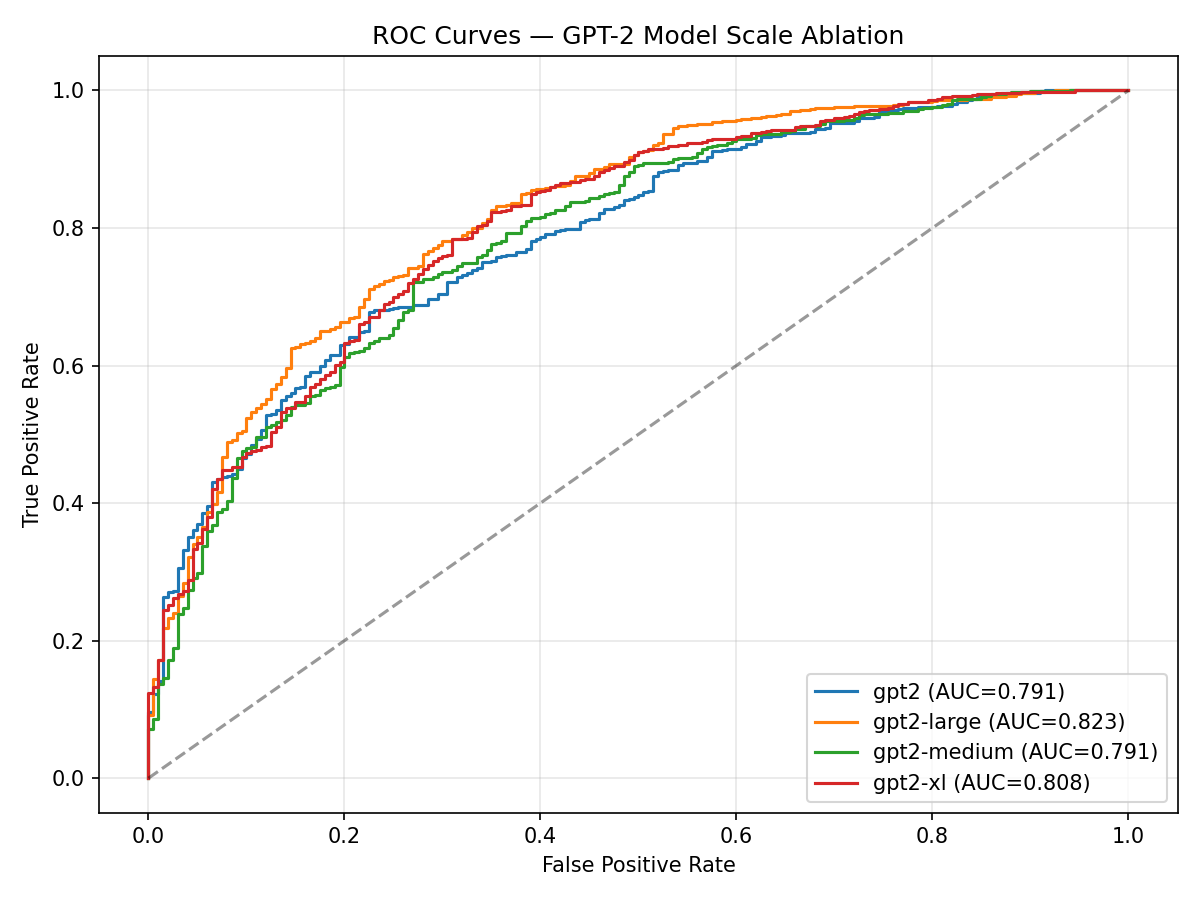

In [9]:
from IPython.display import Image, display
import os, config

roc_path = os.path.join(config.OUTPUT_DIR, 'roc_curves.png')
if os.path.isfile(roc_path):
    display(Image(filename=roc_path))
else:
    print('roc_curves.png not found (ablation models may have been skipped).')


---
## Step 5 — Token-Level NLL Annotation

Computes per-token NLL under the human and pooled-AI models, derives style labels, and generates HTML heatmaps.  
Produces `token_nll_annotations.csv`, `sentence_nll_summary.csv`, and `token_nll_heatmap_samples.html`.

In [10]:
"""Step 5 — Token-level NLL annotation.

Computes per-token NLL under the human and pooled-AI GPT-2 models, derives
style annotations, and generates:

  - ``outputs/token_nll_annotations.csv``
  - ``outputs/sentence_nll_summary.csv``
  - ``outputs/token_nll_heatmap_samples.html``

SEED POLICY: No fixed seed is used for NLL computation.
RANDOM_SEED = 1024 is used ONLY for selecting the 20-sentence heatmap sample.
"""

import os
import sys
import time
import html as html_mod

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats

import config
from utils import (
    set_seed,
    ensure_dir,
    load_finetuned_model,
    compute_token_nll,
)


def _style_label(nll_diff: float) -> str:
    """Assign a style label based on nll_diff = nll_human − nll_ai."""
    if nll_diff >= 1.5:
        return "strongly_ai_style"
    elif nll_diff >= 0.5:
        return "weakly_ai_style"
    elif nll_diff <= -1.5:
        return "strongly_human_style"
    elif nll_diff <= -0.5:
        return "weakly_human_style"
    else:
        return "neutral"


def _nll_diff_to_color(nll_diff: float) -> str:
    """Map nll_diff to a background colour for the HTML heatmap."""
    # Blue = human style (negative diff), Red = AI style (positive diff)
    clamp = max(-3.0, min(3.0, nll_diff))
    if clamp >= 0:
        intensity = int(min(255, clamp / 3.0 * 200))
        return f"rgba(255,{255 - intensity},{255 - intensity},0.7)"
    else:
        intensity = int(min(255, abs(clamp) / 3.0 * 200))
        return f"rgba({255 - intensity},{255 - intensity},255,0.7)"


def main() -> None:
    start = time.time()
    print(f"[Step 5] {time.strftime('%Y-%m-%d %H:%M:%S')} — Token-level NLL annotation …")

    # ── Load prerequisites ───────────────────────────────────────────────────
    split_path = os.path.join(config.OUTPUT_DIR, "train_test_split.csv")
    ai_path = os.path.join(config.OUTPUT_DIR, "ai_translations.csv")
    for p in (split_path, ai_path):
        if not os.path.isfile(p):
            sys.exit(f"ERROR: {p} not found. Run previous steps first.")

    split_df = pd.read_csv(split_path, encoding="utf-8")
    ai_df = pd.read_csv(ai_path, encoding="utf-8")
    test_ids = set(split_df[split_df["split"] == "test"]["sentence_id"])

    # Build test texts
    records: list[dict] = []
    human_df = ai_df.drop_duplicates(subset=["sentence_id"])
    for _, row in human_df.iterrows():
        if row["sentence_id"] in test_ids:
            records.append({"sentence_id": row["sentence_id"], "text_source": "human", "text": row["human_translation_en"]})
    for _, row in ai_df.iterrows():
        if row["sentence_id"] in test_ids:
            records.append({"sentence_id": row["sentence_id"], "text_source": row["ai_system_id"], "text": row["ai_translation_en"]})

    print(f"  Test texts: {len(records)}")

    # ── Load models ──────────────────────────────────────────────────────────
    human_adapter = os.path.join(config.OUTPUT_DIR, "models", config.PRIMARY_MODEL_NAME, "human_lora")
    pooled_adapter = os.path.join(config.OUTPUT_DIR, "models", config.PRIMARY_MODEL_NAME, "pooled_ai_lora")
    for ap in (human_adapter, pooled_adapter):
        if not os.path.isdir(ap):
            sys.exit(f"ERROR: Adapter not found: {ap}. Run step2 first.")

    model_h, tok_h = load_finetuned_model(config.PRIMARY_MODEL_NAME, human_adapter, config.DEVICE)
    model_a, tok_a = load_finetuned_model(config.PRIMARY_MODEL_NAME, pooled_adapter, config.DEVICE)

    # ── Compute token-level NLL ──────────────────────────────────────────────
    all_token_rows: list[dict] = []
    sentence_summaries: list[dict] = []

    for rec in tqdm(records, desc="  Token NLL"):
        tokens_h = compute_token_nll(model_h, tok_h, rec["text"], config.DEVICE)
        tokens_a = compute_token_nll(model_a, tok_a, rec["text"], config.DEVICE)

        # Align by position — both should have the same tokenization (same base tokenizer)
        n = min(len(tokens_h), len(tokens_a))
        if n == 0:
            continue

        sent_nll_h: list[float] = []
        sent_nll_a: list[float] = []

        for i in range(n):
            nll_h = tokens_h[i]["nll"]
            nll_a = tokens_a[i]["nll"]
            nll_diff = nll_h - nll_a
            nll_ratio = nll_h / nll_a if nll_a != 0 else float("inf")

            sent_nll_h.append(nll_h)
            sent_nll_a.append(nll_a)

            all_token_rows.append(
                {
                    "sentence_id": rec["sentence_id"],
                    "text_source": rec["text_source"],
                    "token_position": tokens_h[i]["token_position"],
                    "token": tokens_h[i]["token"],
                    "nll_human": nll_h,
                    "nll_ai": nll_a,
                    "nll_diff": nll_diff,
                    "nll_ratio": nll_ratio,
                    "style_label": _style_label(nll_diff),
                }
            )

        # sentence-level summary
        arr_h = np.array(sent_nll_h)
        arr_a = np.array(sent_nll_a)
        sentence_summaries.append(
            {
                "sentence_id": rec["sentence_id"],
                "text_source": rec["text_source"],
                "mean_nll_human": arr_h.mean(),
                "mean_nll_ai": arr_a.mean(),
                "mean_nll_diff": (arr_h - arr_a).mean(),
                "n_tokens": n,
                "pct_ai_style": sum(1 for r in all_token_rows[-n:] if "ai_style" in r["style_label"]) / n,
                "pct_human_style": sum(1 for r in all_token_rows[-n:] if "human_style" in r["style_label"]) / n,
                "pct_neutral": sum(1 for r in all_token_rows[-n:] if r["style_label"] == "neutral") / n,
            }
        )

    # ── z-scores across the full token set ───────────────────────────────────
    token_df = pd.DataFrame(all_token_rows)
    if len(token_df) > 0:
        token_df["z_nll_human"] = stats.zscore(token_df["nll_human"].values)
        token_df["z_nll_ai"] = stats.zscore(token_df["nll_ai"].values)
    else:
        token_df["z_nll_human"] = []
        token_df["z_nll_ai"] = []

    # ── Save ─────────────────────────────────────────────────────────────────
    ensure_dir(config.OUTPUT_DIR)

    token_path = os.path.join(config.OUTPUT_DIR, "token_nll_annotations.csv")
    token_df.to_csv(token_path, index=False, encoding="utf-8")
    print(f"  Token annotations ({len(token_df)} rows) → {token_path}")

    sent_df = pd.DataFrame(sentence_summaries)
    sent_path = os.path.join(config.OUTPUT_DIR, "sentence_nll_summary.csv")
    sent_df.to_csv(sent_path, index=False, encoding="utf-8")
    print(f"  Sentence summaries ({len(sent_df)} rows) → {sent_path}")

    # ── HTML heatmaps for 20 random sentences ────────────────────────────────
    set_seed(config.RANDOM_SEED)
    unique_keys = token_df[["sentence_id", "text_source"]].drop_duplicates()
    n_sample = min(20, len(unique_keys))
    sample_keys = unique_keys.sample(n=n_sample, random_state=config.RANDOM_SEED)

    html_parts: list[str] = [
        "<!DOCTYPE html><html><head><meta charset='utf-8'>",
        "<title>Token NLL Heatmaps</title>",
        "<style>body{font-family:monospace;margin:20px} .sent{margin-bottom:20px;} "
        ".token{display:inline-block;padding:2px 1px;margin:1px;border-radius:3px;} "
        "h3{margin-bottom:4px;} .legend{margin-bottom:20px;}</style></head><body>",
        "<h1>Token NLL Heatmap Samples</h1>",
        "<div class='legend'><b>Color key:</b> "
        "<span style='background:rgba(100,100,255,0.7);padding:2px 6px;'>human-style</span> "
        "<span style='background:rgba(240,240,240,0.7);padding:2px 6px;'>neutral</span> "
        "<span style='background:rgba(255,100,100,0.7);padding:2px 6px;'>AI-style</span></div>",
    ]

    for _, key_row in sample_keys.iterrows():
        sid = key_row["sentence_id"]
        src = key_row["text_source"]
        subset = token_df[(token_df["sentence_id"] == sid) & (token_df["text_source"] == src)]
        html_parts.append(f"<div class='sent'><h3>{html_mod.escape(str(sid))} ({html_mod.escape(str(src))})</h3>")
        for _, tok_row in subset.iterrows():
            color = _nll_diff_to_color(tok_row["nll_diff"])
            escaped = html_mod.escape(tok_row["token"])
            title = f"nll_h={tok_row['nll_human']:.2f} nll_a={tok_row['nll_ai']:.2f} diff={tok_row['nll_diff']:.2f}"
            html_parts.append(f"<span class='token' style='background:{color}' title='{title}'>{escaped}</span>")
        html_parts.append("</div>")

    html_parts.append("</body></html>")
    html_path = os.path.join(config.OUTPUT_DIR, "token_nll_heatmap_samples.html")
    with open(html_path, "w", encoding="utf-8") as f:
        f.write("\n".join(html_parts))
    print(f"  Heatmaps → {html_path}")

    elapsed = time.time() - start
    print(f"\n[Step 5] Done in {elapsed:.1f}s.")

main()

[Step 5] 2026-03-18 05:59:42 — Token-level NLL annotation …
  Test texts: 1000


  Token NLL: 100%|██████████| 1000/1000 [00:27<00:00, 36.59it/s]


  Token annotations (49290 rows) → /notebooks/ai_translation/outputs/token_nll_annotations.csv
  Sentence summaries (1000 rows) → /notebooks/ai_translation/outputs/sentence_nll_summary.csv
  Heatmaps → /notebooks/ai_translation/outputs/token_nll_heatmap_samples.html

[Step 5] Done in 30.5s.


### Display Token-Level Heatmap

In [ ]:
from IPython.display import HTML, display
import os, config

heatmap_path = os.path.join(config.OUTPUT_DIR, 'token_nll_heatmap_samples.html')
if os.path.isfile(heatmap_path):
    with open(heatmap_path, 'r', encoding='utf-8') as f:
        display(HTML(f.read()))
else:
    print('Heatmap HTML not found.')


---
## Step 6 — Probe Translation Models & GPT-2 Baselines

Probes unfinetuned GPT-2 variants and fine-tuned adapters with Wilcoxon tests and AUROC.  
Produces `probe_results.csv`.

In [ ]:
"""Step 6 — Probe translation models and unfinetuned GPT-2 baselines.

Computes sentence-level perplexity using each unfinetuned GPT-2 variant and
performs statistical tests comparing human vs. AI texts.

Produces ``outputs/probe_results.csv``.

SEED POLICY: No fixed seed is used for inference.
"""

import os
import sys
import time

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import wilcoxon
from sklearn.metrics import roc_auc_score

import config
from utils import (
    ensure_dir,
    load_base_model,
    load_finetuned_model,
    compute_perplexity,
)


def _probe_one_model(
    model,
    tokenizer,
    records: list[dict],
    device: str,
) -> pd.DataFrame:
    """Compute perplexity for every record and return a DataFrame."""
    rows: list[dict] = []
    for rec in tqdm(records, desc="    Probing", leave=False):
        ppl, avg_nll = compute_perplexity(
            model, tokenizer, rec["text"],
            max_length=1024, stride=config.STRIDE, device=device,
        )
        rows.append({
            "sentence_id": rec["sentence_id"],
            "text_source": rec["text_source"],
            "ppl": ppl,
            "avg_nll": avg_nll,
        })
    return pd.DataFrame(rows)


def _compute_stats(
    probe_df: pd.DataFrame,
    probe_model: str,
    finetuned: bool,
) -> list[dict]:
    """Compute per-source statistics and Wilcoxon test (human vs each AI)."""
    results: list[dict] = []
    human_ppls = probe_df[probe_df["text_source"] == "human"]["ppl"].values

    for src in probe_df["text_source"].unique():
        sub = probe_df[probe_df["text_source"] == src]
        mean_ppl = sub["ppl"].mean()
        std_ppl = sub["ppl"].std()

        # Wilcoxon test: human vs. this source
        w_stat, w_p, effect = float("nan"), float("nan"), float("nan")
        auroc = float("nan")
        if src != "human" and len(human_ppls) > 0 and len(sub) > 0:
            ai_ppls = sub["ppl"].values
            n = min(len(human_ppls), len(ai_ppls))
            if n > 10:
                try:
                    w_stat, w_p = wilcoxon(human_ppls[:n], ai_ppls[:n])
                    # rank-biserial effect size approximation
                    effect = 1 - (2 * w_stat) / (n * (n + 1))
                except Exception:
                    pass
            # AUROC: can perplexity from this model separate human from this AI?
            labels = np.array([0] * len(human_ppls) + [1] * len(ai_ppls))
            scores = np.concatenate([human_ppls, ai_ppls])
            if len(set(labels)) > 1:
                try:
                    auroc = roc_auc_score(labels, scores)
                except Exception:
                    pass

        results.append({
            "probe_model": probe_model,
            "finetuned": finetuned,
            "text_source": src,
            "mean_ppl": mean_ppl,
            "std_ppl": std_ppl,
            "wilcoxon_stat": w_stat,
            "wilcoxon_p": w_p,
            "effect_size": effect,
            "detection_auroc": auroc,
        })

    return results


def main() -> None:
    start = time.time()
    print(f"[Step 6] {time.strftime('%Y-%m-%d %H:%M:%S')} — Probing models …")

    # ── Load test texts ──────────────────────────────────────────────────────
    split_path = os.path.join(config.OUTPUT_DIR, "train_test_split.csv")
    ai_path = os.path.join(config.OUTPUT_DIR, "ai_translations.csv")
    for p in (split_path, ai_path):
        if not os.path.isfile(p):
            sys.exit(f"ERROR: {p} not found. Run previous steps first.")

    split_df = pd.read_csv(split_path, encoding="utf-8")
    ai_df = pd.read_csv(ai_path, encoding="utf-8")
    test_ids = set(split_df[split_df["split"] == "test"]["sentence_id"])

    records: list[dict] = []
    human_df = ai_df.drop_duplicates(subset=["sentence_id"])
    for _, row in human_df.iterrows():
        if row["sentence_id"] in test_ids:
            records.append({"sentence_id": row["sentence_id"], "text_source": "human", "text": row["human_translation_en"]})
    for _, row in ai_df.iterrows():
        if row["sentence_id"] in test_ids:
            records.append({"sentence_id": row["sentence_id"], "text_source": row["ai_system_id"], "text": row["ai_translation_en"]})

    print(f"  Test texts: {len(records)}")

    all_results: list[dict] = []

    # ── 1. Probe unfinetuned GPT-2 variants ──────────────────────────────────
    for variant in config.GPT2_VARIANTS:
        print(f"\n  Probing unfinetuned {variant} …")
        try:
            model, tokenizer = load_base_model(variant, config.DEVICE)
            probe_df = _probe_one_model(model, tokenizer, records, config.DEVICE)
            results = _compute_stats(probe_df, variant, finetuned=False)
            all_results.extend(results)
            del model
            import torch
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
        except Exception as e:
            print(f"  WARNING: Failed to probe {variant}: {e}")

    # ── 2. Probe fine-tuned adapters (for comparison) ────────────────────────
    model_base_dir = os.path.join(config.OUTPUT_DIR, "models", config.PRIMARY_MODEL_NAME)
    if os.path.isdir(model_base_dir):
        for name in sorted(os.listdir(model_base_dir)):
            adapter_path = os.path.join(model_base_dir, name)
            if os.path.isdir(adapter_path) and name.endswith("_lora"):
                style = name.replace("_lora", "")
                probe_name = f"{config.PRIMARY_MODEL_NAME}+{style}_lora"
                print(f"\n  Probing fine-tuned {probe_name} …")
                try:
                    model, tokenizer = load_finetuned_model(
                        config.PRIMARY_MODEL_NAME, adapter_path, config.DEVICE
                    )
                    probe_df = _probe_one_model(model, tokenizer, records, config.DEVICE)
                    results = _compute_stats(probe_df, probe_name, finetuned=True)
                    all_results.extend(results)
                    del model
                    import torch
                    torch.cuda.empty_cache() if torch.cuda.is_available() else None
                except Exception as e:
                    print(f"  WARNING: Failed to probe {probe_name}: {e}")

    # ── 3. Probe local translation models (placeholder) ─────────────────────
    print("\n  NOTE: No local translation models detected — skipping translation model probes.")

    # ── Save ─────────────────────────────────────────────────────────────────
    out_df = pd.DataFrame(all_results)
    ensure_dir(config.OUTPUT_DIR)
    out_path = os.path.join(config.OUTPUT_DIR, "probe_results.csv")
    out_df.to_csv(out_path, index=False, encoding="utf-8")
    print(f"\n  Probe results ({len(out_df)} rows) → {out_path}")

    elapsed = time.time() - start
    print(f"\n[Step 6] Done in {elapsed:.1f}s.")

main()

[Step 6] 2026-03-18 06:00:12 — Probing models …
  Test texts: 1000

  Probing unfinetuned gpt2 …



  Probing unfinetuned gpt2-medium …



  Probing unfinetuned gpt2-large …



  Probing unfinetuned gpt2-xl …



  Probing fine-tuned gpt2+gpt-5-mini_lora …


...


  Probing fine-tuned gpt2+grok-3_lora …



  Probing fine-tuned gpt2+human_lora …



  Probing fine-tuned gpt2+llama-3.3-70b-instruct_lora …



  Probing fine-tuned gpt2+pooled_ai_lora …



  NOTE: No local translation models detected — skipping translation model probes.

  Probe results (50 rows) → /notebooks/ai_translation/outputs/probe_results.csv

[Step 6] Done in 177.3s.


---
## Step 7 — Generate Summary Report

Compiles all experiment outputs into `summary_report.csv` and prints a human-readable overview.

In [ ]:
"""Step 7 — Generate summary report.

Compiles all experiment outputs into ``outputs/summary_report.csv`` and
prints a human-readable summary to stdout.
"""

import os
import sys
import time

import pandas as pd

import config
from utils import ensure_dir


def _try_load(name: str) -> pd.DataFrame | None:
    """Attempt to load a CSV from OUTPUT_DIR, return None on failure."""
    path = os.path.join(config.OUTPUT_DIR, name)
    if not os.path.isfile(path):
        print(f"  WARNING: {name} not found — skipping")
        return None
    return pd.read_csv(path, encoding="utf-8")


def main() -> None:
    start = time.time()
    print(f"[Step 7] {time.strftime('%Y-%m-%d %H:%M:%S')} — Generating summary report …")

    rows: list[dict] = []

    # ── Corpus statistics ────────────────────────────────────────────────────
    corpus = _try_load("corpus_prepared.csv")
    if corpus is not None:
        en_lens = corpus["human_translation_en"].str.split().str.len()
        zh_lens = corpus["source_zh"].str.len()
        rows.append({"section": "corpus_stats", "metric": "total_sentences", "value": str(len(corpus))})
        rows.append({"section": "corpus_stats", "metric": "mean_en_tokens", "value": f"{en_lens.mean():.1f}"})
        rows.append({"section": "corpus_stats", "metric": "median_en_tokens", "value": f"{en_lens.median():.1f}"})
        rows.append({"section": "corpus_stats", "metric": "mean_zh_chars", "value": f"{zh_lens.mean():.1f}"})
        rows.append({"section": "corpus_stats", "metric": "median_zh_chars", "value": f"{zh_lens.median():.1f}"})

    # ── Finetune summary ─────────────────────────────────────────────────────
    ft = _try_load("finetune_summary.csv")
    if ft is not None:
        for _, r in ft.iterrows():
            rows.append({
                "section": "finetune_summary",
                "metric": f"{r['base_model']}_{r['style']}_val_ppl",
                "value": f"{r['final_val_ppl']:.2f}",
            })
            rows.append({
                "section": "finetune_summary",
                "metric": f"{r['base_model']}_{r['style']}_val_loss",
                "value": f"{r['final_val_loss']:.4f}",
            })

    # ── Classification best results ──────────────────────────────────────────
    clf = _try_load("classification_results.csv")
    if clf is not None:
        # Best per experiment
        for exp in clf["experiment"].unique():
            sub = clf[clf["experiment"] == exp]
            best = sub.loc[sub["f1"].idxmax()]
            rows.append({
                "section": "classification_best",
                "metric": f"{exp}_best_classifier",
                "value": best["classifier"],
            })
            for m in ["accuracy", "precision", "recall", "f1", "auroc"]:
                rows.append({
                    "section": "classification_best",
                    "metric": f"{exp}_best_{m}",
                    "value": f"{best[m]:.4f}",
                })

    # ── Token annotation statistics ──────────────────────────────────────────
    tok = _try_load("token_nll_annotations.csv")
    if tok is not None:
        rows.append({"section": "token_annotation_stats", "metric": "total_tokens", "value": str(len(tok))})
        for label in tok["style_label"].unique():
            count = (tok["style_label"] == label).sum()
            pct = count / len(tok) * 100
            rows.append({
                "section": "token_annotation_stats",
                "metric": f"pct_{label}",
                "value": f"{pct:.1f}%",
            })

    # ── Sentence NLL summary ─────────────────────────────────────────────────
    sent = _try_load("sentence_nll_summary.csv")
    if sent is not None:
        rows.append({"section": "token_annotation_stats", "metric": "total_sentences_annotated", "value": str(len(sent))})
        rows.append({"section": "token_annotation_stats", "metric": "mean_nll_diff",
                      "value": f"{sent['mean_nll_diff'].mean():.4f}"})

    # ── Probe summary ────────────────────────────────────────────────────────
    probe = _try_load("probe_results.csv")
    if probe is not None:
        for _, r in probe.iterrows():
            rows.append({
                "section": "probe_summary",
                "metric": f"{r['probe_model']}_{'ft' if r['finetuned'] else 'base'}_{r['text_source']}_mean_ppl",
                "value": f"{r['mean_ppl']:.2f}",
            })
            if pd.notna(r.get("detection_auroc")) and r["text_source"] != "human":
                rows.append({
                    "section": "probe_summary",
                    "metric": f"{r['probe_model']}_{'ft' if r['finetuned'] else 'base'}_{r['text_source']}_auroc",
                    "value": f"{r['detection_auroc']:.4f}",
                })

    # ── Save ─────────────────────────────────────────────────────────────────
    report_df = pd.DataFrame(rows)
    ensure_dir(config.OUTPUT_DIR)
    out_path = os.path.join(config.OUTPUT_DIR, "summary_report.csv")
    report_df.to_csv(out_path, index=False, encoding="utf-8")
    print(f"  Summary report ({len(report_df)} rows) → {out_path}")

    # ── Human-readable stdout ────────────────────────────────────────────────
    print("\n  ╔══════════════════════════════════════════════════════════════╗")
    print("  ║              AI Translation Style Detection Report          ║")
    print("  ╚══════════════════════════════════════════════════════════════╝\n")

    for section in report_df["section"].unique():
        print(f"  [{section}]")
        sub = report_df[report_df["section"] == section]
        for _, r in sub.iterrows():
            print(f"    {r['metric']}: {r['value']}")
        print()

    elapsed = time.time() - start
    print(f"[Step 7] Done in {elapsed:.1f}s.")

main()

[Step 7] 2026-03-18 06:03:10 — Generating summary report …
  Summary report (157 rows) → /notebooks/ai_translation/outputs/summary_report.csv

  ╔══════════════════════════════════════════════════════════════╗
  ║              AI Translation Style Detection Report          ║
  ╚══════════════════════════════════════════════════════════════╝

  [corpus_stats]
    total_sentences: 2000
    mean_en_tokens: 43.5
    median_en_tokens: 40.0
    mean_zh_chars: 76.8
    median_zh_chars: 71.0

  [finetune_summary]
    gpt2_human_val_ppl: 37.91
    gpt2_human_val_loss: 3.6351
    gpt2_gpt-5_val_ppl: 30.11
    gpt2_gpt-5_val_loss: 3.4047
    gpt2_gpt-5-mini_val_ppl: 30.95
    gpt2_gpt-5-mini_val_loss: 3.4324
    gpt2_grok-3_val_ppl: 28.66
    gpt2_grok-3_val_loss: 3.3556
    gpt2_llama-3.3-70b-instruct_val_ppl: 28.89
    gpt2_llama-3.3-70b-instruct_val_loss: 3.3634
    gpt2_pooled_ai_val_ppl: 27.28
    gpt2_pooled_ai_val_loss: 3.3061

  [classification_best]
    two_feature_best_classifier: Logis

---
## Pipeline Complete — Output Files

In [ ]:
import os, config

print('Output directory:', config.OUTPUT_DIR)
print()
for root, dirs, files in os.walk(config.OUTPUT_DIR):
    level = root.replace(config.OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = '  ' * (level + 1)
    for f in sorted(files):
        size = os.path.getsize(os.path.join(root, f))
        print(f'{sub_indent}{f}  ({size:,} bytes)')


Output directory: /notebooks/ai_translation/outputs

outputs/
  ai_translations.csv  (3,306,689 bytes)
  classification_results.csv  (3,710 bytes)
  corpus_prepared.csv  (1,071,138 bytes)
  finetune_summary.csv  (485 bytes)
  perplexity_matrix.csv  (545,506 bytes)
  probe_results.csv  (5,976 bytes)
  roc_curves.png  (92,810 bytes)
  sentence_nll_summary.csv  (155,738 bytes)
  summary_report.csv  (9,233 bytes)
  token_nll_annotations.csv  (8,780,530 bytes)
  token_nll_heatmap_samples.html  (122,717 bytes)
  train_test_split.csv  (38,818 bytes)
  finetune_logs/
    gpt2_grok-3/
      checkpoint-400/
        README.md  (5,103 bytes)
        adapter_config.json  (469 bytes)
        adapter_model.safetensors  (3,253,104 bytes)
        optimizer.pt  (6,548,858 bytes)
        rng_state.pth  (14,244 bytes)
        scheduler.pt  (1,064 bytes)
        trainer_state.json  (2,077 bytes)
        training_args.bin  (4,664 bytes)
      checkpoint-600/
        README.md  (5,103 bytes)
        adapter_